In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
import re

def find_max_hardness_json(root_dir):
    """
    루트 디렉토리를 순회하며 각 데이터셋 폴더 내의 hardness 또는 report 폴더에서
    가장 큰 숫자를 가진 hardness_v5.1_{숫자}.json 파일의 경로를 찾습니다.
    """
    
    # 결과를 저장할 딕셔너리 (데이터셋 이름: 찾은 파일 경로)
    result_paths = {}

    # 1. 루트 디렉토리의 모든 하위 항목(데이터셋 폴더들) 순회
    # 예: sift1m_original, gist_high 등
    if not os.path.exists(root_dir):
        print(f"Error: 경로가 존재하지 않습니다 -> {root_dir}")
        return {}

    for dataset_name in os.listdir(root_dir):
        dataset_path = os.path.join(root_dir, dataset_name)
        
        # 디렉토리가 아닌 경우 건너뜀
        if not os.path.isdir(dataset_path):
            continue

        # 2. 탐색할 타겟 서브 디렉토리 후보 (hardness 또는 report)
        target_subdirs = ['hardness', 'report']
        found_files = []

        for subdir in target_subdirs:
            target_path = os.path.join(dataset_path, subdir)
            
            # 해당 서브 디렉토리가 존재하는지 확인
            if os.path.exists(target_path) and os.path.isdir(target_path):
                # 파일 패턴 매칭: hardness_v5.1_{숫자}.json
                # 정규표현식: hardness_v5\.1_(\d+)\.json
                pattern = re.compile(r'hardness_v5\.1_(\d+)\.json')
                
                for filename in os.listdir(target_path):
                    match = pattern.match(filename)
                    if match:
                        num = int(match.group(1)) # 숫자 부분 추출 (예: 10000)
                        full_path = os.path.join(target_path, filename)
                        found_files.append((num, full_path))

        # 3. 찾은 파일들 중 숫자가 가장 큰 파일 선택
        if found_files:
            # 숫자(x[0])를 기준으로 내림차순 정렬 후 첫 번째 요소 선택
            found_files.sort(key=lambda x: x[0], reverse=True)
            max_file_path = found_files[0][1]
            result_paths[dataset_name] = max_file_path

    return result_paths

# --- 사용 예시 ---

# 실제 'Benchmark' 폴더가 있는 경로를 입력해주세요.
# 현재 실행 위치에 있다면 './Benchmark' 혹은 절대 경로 입력
root_directory = '/home/ec2-user/hybrid_hardness/Benchmark' 
root_directory2 = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark"

paths1 = find_max_hardness_json(root_directory)
paths2 = find_max_hardness_json(root_directory2)

print(f"총 {len(paths1)+len(paths2)}개의 경로를 찾았습니다.\n")



총 35개의 경로를 찾았습니다.



In [4]:
paths1.keys()

dict_keys(['sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0', 'sift1m_A1_12_zipf_0.5_0.0', 'sift1m_A3_12_12_12_zipf_0.5_0.5_0.5_0.0_0.0_0.0', 'sift1m_A12_1_1_1_1_1_1_1_1_1_1_1_1_zipf_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0', 'sift1m_A12_3_3_3_3_3_3_3_3_3_3_3_3_zipf_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0', 'sift1m_A12_6_6_6_6_6_6_6_6_6_6_6_6_zipf_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0', 'sift1m_A12_12_12_12_12_12_12_12_12_12_12_12_12_zipf_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0', 'sift1m_A3_12_12_12_random_0.5_0.5_0.5_0.0_0.0_0.0', 'sift1m_A12_3_3_3_3_3_3_3_3_3_3_3_3_random_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.5_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0', 'sift1m_A3_12_12_12_zipf_0.5_0.5_0.5_0.5_0.5_0.5', 'sift1m_A3_12_12_12_zipf_0.5_0.5_0.5_1.0_1.0_1.0

[INFO] Total paths to plot: 12
[INFO] Total names provided: 12
[Plotting 1/12] Synthetic: ACORN
[Plotting 2/12] Synthetic: NHQ
[Plotting 3/12] Synthetic: UNG
[Plotting 4/12] Synthetic: RWalks
[Plotting 5/12] Semi-Real: arxiv
[Plotting 6/12] Semi-Real: LAION1M
[Plotting 7/12] Semi-Real: tripclick
[Plotting 8/12] Semi-Real: yfcc
[Plotting 9/12] Generated: SIFT-High
[Plotting 10/12] Generated: SIFT-Low
[Plotting 11/12] Generated: GIST-High
[Plotting 12/12] Generated: GIST-Low


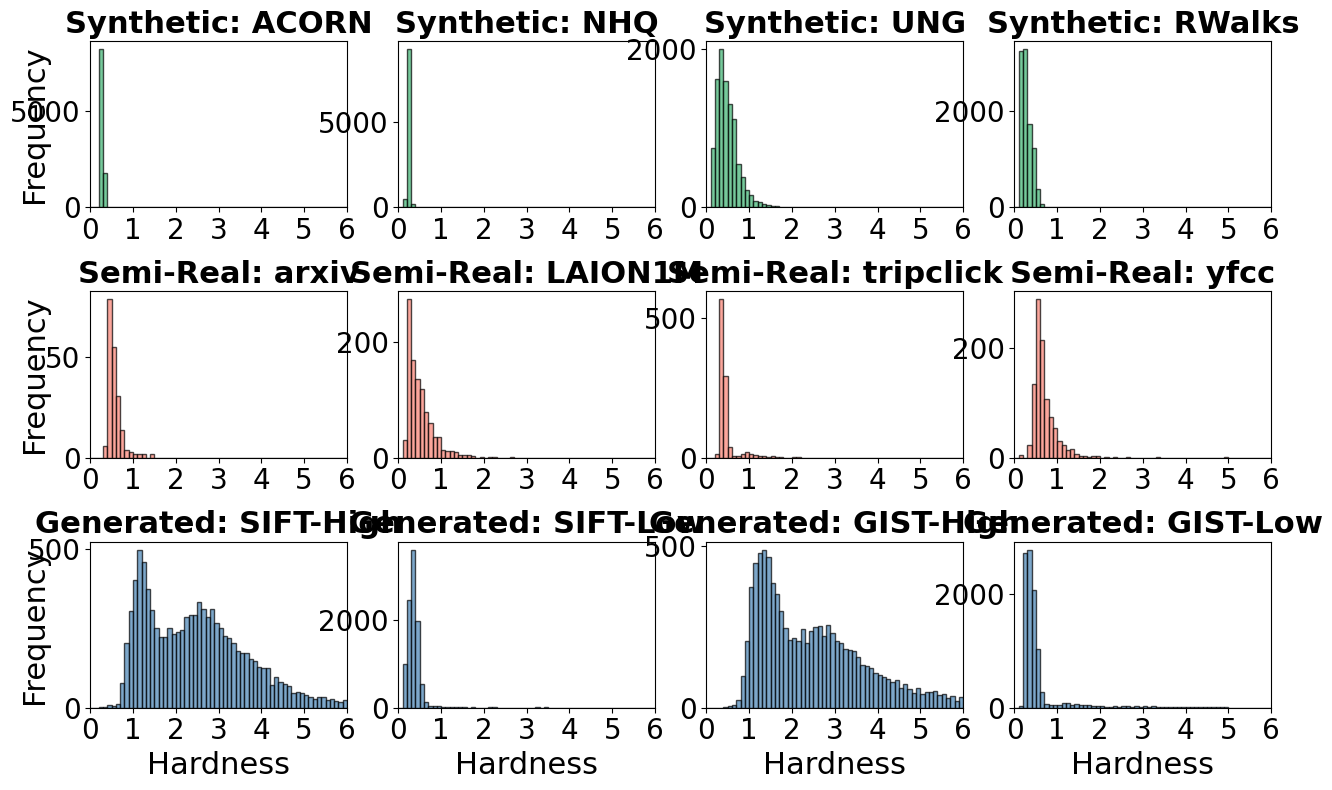

[INFO] PDF Saved: hardness_distribution.pdf


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# -------------------------------------------------
# 0) 경로 및 이름 리스트 구성
# -------------------------------------------------
path_list = []
name_list = []

# (이전과 동일한 리스트 구성 코드 생략... 사용자 환경에 맞게 유지)
if "sift1m_ACORN" in paths1:
    path_list.append(paths1["sift1m_ACORN"])
    name_list.append("Synthetic: ACORN")
if "sift1m_NHQ" in paths1:
    path_list.append("/home/ec2-user/hybrid_hardness/Benchmark/sift1m_NHQ/hardness/hardness_v4.2_10000.json")
    name_list.append("Synthetic: NHQ")
if "sift1m_UNG" in paths1:
    path_list.append(paths1["sift1m_UNG"])
    name_list.append("Synthetic: UNG")
if "sift1m_RWalks" in paths1:
    path_list.append(paths1["sift1m_RWalks"])
    name_list.append("Synthetic: RWalks")

# for key, path in paths2.items():
#     if key != "ytb_audio":
#         path_list.append(path)
#         name_list.append(f"Semi-Real: {key}")
if "arxiv" in paths2:
    path_list.append(paths2["arxiv"])
    name_list.append("Semi-Real: arxiv")
if "LAION1M" in paths2:
    path_list.append(paths2["LAION1M"])
    name_list.append("Semi-Real: LAION1M")
if "tripclick" in paths2:
    path_list.append(paths2["tripclick"])
    name_list.append("Semi-Real: tripclick")
if "yfcc" in paths2:
    path_list.append(paths2["yfcc"])
    name_list.append("Semi-Real: yfcc")



if "sift_high" in paths1:
    path_list.append(paths1["sift_high"])
    name_list.append("Generated: SIFT-High")
if "sift_low" in paths1:
    path_list.append(paths1["sift_low"])
    name_list.append("Generated: SIFT-Low")
if "gist_high" in paths1:
    path_list.append(paths1["gist_high"])
    name_list.append("Generated: GIST-High")
if "gist_low" in paths1:
    path_list.append(paths1["gist_low"])
    name_list.append("Generated: GIST-Low")

# paths1['sift1m_NHQ'] = '/home/ec2-user/hybrid_hardness/Benchmark/sift1m_NHQ/hardness/hardness_v4.2_10000.json'
# -------------------------------------------------
# 1) 3x4 서브플롯 생성
# -------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(13, 8))
axes_flat = axes.flatten()

MAX_PLOTS = 12

print(f"[INFO] Total paths to plot: {len(path_list)}")
print(f"[INFO] Total names provided: {len(name_list)}")

# -------------------------------------------------
# 2) 반복문으로 차트 그리기
# -------------------------------------------------
for i, json_path in enumerate(path_list):
    if i >= MAX_PLOTS:
        print(f"[WARNING] {MAX_PLOTS}개를 초과하여 생략됨: {json_path}")
        break

    ax = axes_flat[i]

    # --- 제목 결정 ---
    if i < len(name_list):
        chart_title = name_list[i]
    else:
        chart_title = os.path.basename(os.path.dirname(json_path)) or os.path.basename(json_path)

    print(f"[Plotting {i+1}/{MAX_PLOTS}] {chart_title}")

    # --- JSON 읽기 ---
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[ERROR] {e}")
        ax.text(0.5, 0.5, "Error loading file", ha='center', fontweight='bold')
        continue

    # 값 추출
    post_values = np.array([row["Post_Hardness"] for row in data])

    # --- 히스토그램 ---
    bin_edges = np.linspace(0.0, 6.0, 61)

    # 색상 지정
    if i in [0,1,2,3]:
        color = "mediumseagreen"
    elif i in [4,5,6,7]:
        color = "salmon"
    else:
        color = "steelblue"

    ax.hist(
        post_values,
        bins=bin_edges,
        alpha=0.7,
        color=color,
        edgecolor="black"
    )

    # ----------------------------
    # 제목 + 전역 글씨 Bold
    # ----------------------------
    ax.set_title(chart_title, fontsize=22, fontweight='bold')

    # ----------------------------
    # X label: 마지막 행만 출력(i >= 8)
    # ----------------------------
    if i >= 8:  
        ax.set_xlabel("Hardness", fontsize=22)
    else:
        ax.set_xlabel("")  # 숨김

    # ----------------------------
    # 왼쪽 열만 Y label 출력
    # ----------------------------
    if i % 4 == 0:
        ax.set_ylabel("Frequency", fontsize=22)
        ax.yaxis.set_label_coords(-0.16, 0.5)  # 👈 위치 강제 고정


    ax.set_xlim(0.0, 6.0)
    ax.set_xticks(np.arange(0.0, 6.0 + 0.5, 1.0))
    ax.tick_params(axis='both', labelsize=20)

# -------------------------------------------------
# 3) 빈 차트 숨기기
# -------------------------------------------------
for j in range(len(path_list), MAX_PLOTS):
    axes_flat[j].axis('off')


plt.tight_layout()
plt.subplots_adjust(wspace=0.2)   # 👈 좌우 간격 조절 (기본값 0.2보다 넓게)

plt.show()
fig.savefig("hardness_distribution.pdf", bbox_inches='tight')
print("[INFO] PDF Saved: hardness_distribution.pdf")
plt.close(fig)


[INFO] Total paths to plot: 12
[INFO] Total names provided: 12
[Plotting 1/12] ACORN
[Plotting 2/12] NHQ
[Plotting 3/12] UNG
[Plotting 4/12] RWalks
[Plotting 5/12] arxiv
[Plotting 6/12] LAION1M
[Plotting 7/12] tripclick
[Plotting 8/12] yfcc
[Plotting 9/12] SIFT-High
[Plotting 10/12] SIFT-Low
[Plotting 11/12] GIST-High
[Plotting 12/12] GIST-Low


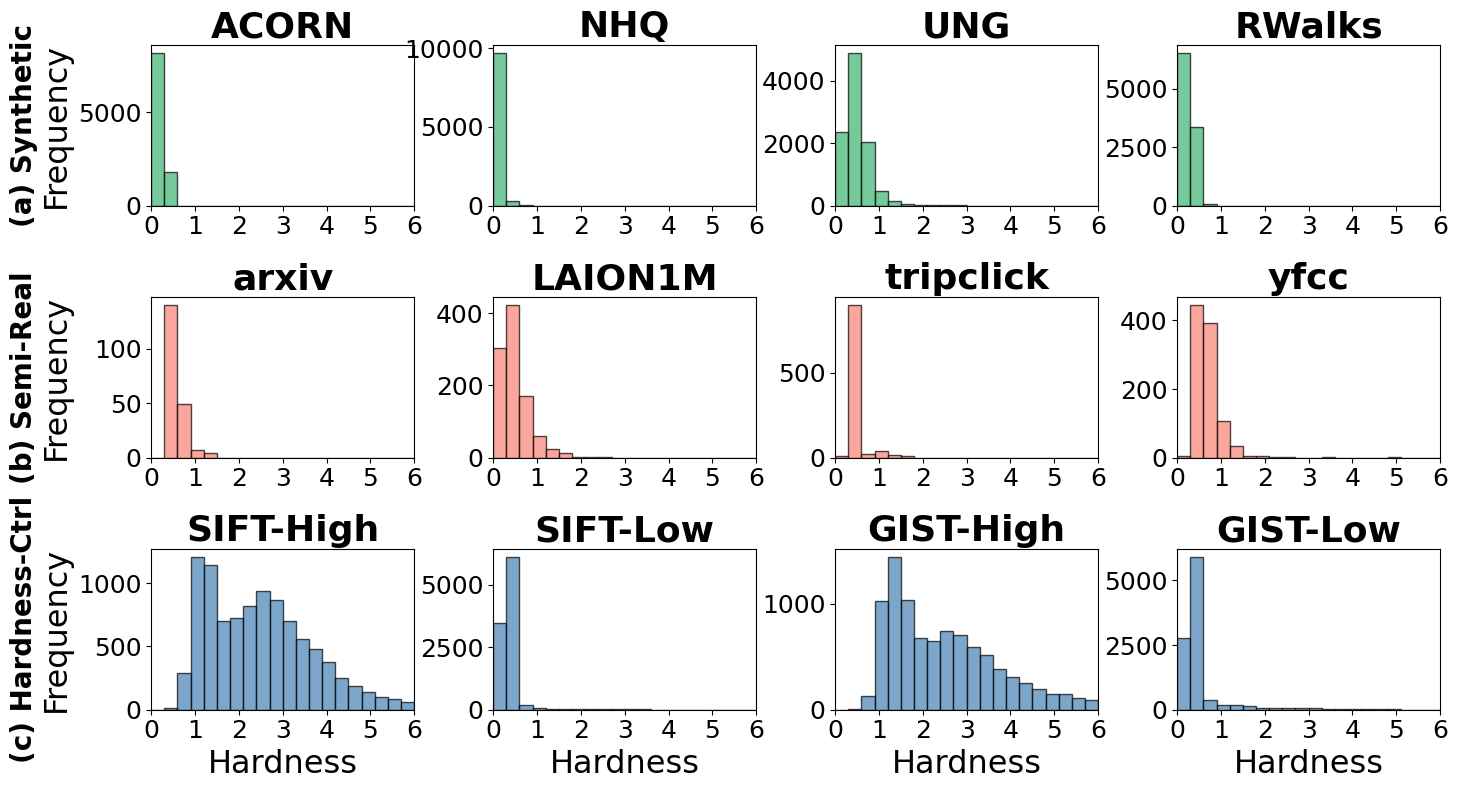

[INFO] PDF Saved: hardness_distribution.pdf


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# -------------------------------------------------
# 0) 경로 및 이름 리스트 구성
# -------------------------------------------------
path_list = []
name_list = []

# Synthetic (paths1)
if "sift1m_ACORN" in paths1:
    path_list.append(paths1["sift1m_ACORN"])
    name_list.append("ACORN")
if "sift1m_NHQ" in paths1:
    path_list.append("/home/ec2-user/hybrid_hardness/Benchmark/sift1m_NHQ/hardness/hardness_v4.2_10000.json")
    name_list.append("NHQ")
if "sift1m_UNG" in paths1:
    path_list.append(paths1["sift1m_UNG"])
    name_list.append("UNG")
if "sift1m_RWalks" in paths1:
    path_list.append(paths1["sift1m_RWalks"])
    name_list.append("RWalks")

# Semi-Real (paths2)
if "arxiv" in paths2:
    path_list.append(paths2["arxiv"])
    name_list.append("arxiv")
if "LAION1M" in paths2:
    path_list.append(paths2["LAION1M"])
    name_list.append("LAION1M")
if "tripclick" in paths2:
    path_list.append(paths2["tripclick"])
    name_list.append("tripclick")
if "yfcc" in paths2:
    path_list.append(paths2["yfcc"])
    name_list.append("yfcc")

# Generated (paths1)
if "sift_high" in paths1:
    path_list.append(paths1["sift_high"])
    name_list.append("SIFT-High")
if "sift_low" in paths1:
    path_list.append(paths1["sift_low"])
    name_list.append("SIFT-Low")
if "gist_high" in paths1:
    path_list.append(paths1["gist_high"])
    name_list.append("GIST-High")
if "gist_low" in paths1:
    path_list.append(paths1["gist_low"])
    name_list.append("GIST-Low")


# -------------------------------------------------
# 1) 3x4 서브플롯 생성
# -------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes_flat = axes.flatten()

MAX_PLOTS = 12

print(f"[INFO] Total paths to plot: {len(path_list)}")
print(f"[INFO] Total names provided: {len(name_list)}")


# -------------------------------------------------
# 2) 반복문으로 차트 그리기
# -------------------------------------------------
for i, json_path in enumerate(path_list):
    if i >= MAX_PLOTS:
        print(f"[WARNING] {MAX_PLOTS}개를 초과하여 생략됨: {json_path}")
        break

    ax = axes_flat[i]

    # 제목 설정
    chart_title = name_list[i] if i < len(name_list) else os.path.basename(json_path)
    print(f"[Plotting {i+1}/{MAX_PLOTS}] {chart_title}")

    # JSON 읽기
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[ERROR] {e}")
        ax.text(0.5, 0.5, "Error loading file", ha='center', fontweight='bold')
        continue

    # 값 추출
    post_values = np.array([row["Post_Hardness"] for row in data])

    # 히스토그램 설정
    bin_edges = np.linspace(0.0, 6.0, 21)

    # 색상 그룹
    if i in [0, 1, 2, 3]:
        color = "mediumseagreen"   # Synthetic
    elif i in [4, 5, 6, 7]:
        color = "salmon"           # Semi-Real
    else:
        color = "steelblue"        # Generated

    ax.hist(
        post_values,
        bins=bin_edges,
        alpha=0.7,
        color=color,
        edgecolor="black"
    )

    # 제목
    ax.set_title(chart_title, fontsize=26, fontweight='bold')

    # X label: 마지막 행만
    if i >= 8:
        ax.set_xlabel("Hardness", fontsize=23)
    else:
        ax.set_xlabel("")

    # Y label: 왼쪽 열만 + 고정 위치
    if i % 4 == 0:
        ax.set_ylabel("Frequency", fontsize=23)
        ax.yaxis.set_label_coords(-0.3, 0.5)

    ax.set_xlim(0.0, 6.0)
    ax.set_xticks(np.arange(0.0, 6.0 + 0.5, 1.0))
    ax.tick_params(axis='both', labelsize=18)

# -------------------------------------------------
# 3) 빈 차트 숨기기
# -------------------------------------------------
for j in range(len(path_list), MAX_PLOTS):
    axes_flat[j].axis('off')


# -------------------------------------------------
# 4) Row-wise 레이블 (왼쪽 바깥, 90도 회전)
# -------------------------------------------------
row_labels = ["(a) Synthetic", "(b) Semi-Real", "(c) Hardness-Ctrl"]

for row_idx, row_label in enumerate(row_labels):
    ax_row = axes[row_idx, 0]
    ax_row.text(
        -0.43, 0.5,
        row_label,
        transform=ax_row.transAxes,
        ha="right",
        va="center",
        fontsize=20,
        fontweight="bold",
        rotation=90,        # ⬅ 반시계 90도 회전
    )


# -------------------------------------------------
# 5) Layout & Save
# -------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(left=0.18, wspace=0.3)  # left 조금 더 넉넉하게

plt.show()
fig.savefig("hardness_distribution_modi_new.pdf", bbox_inches='tight')
print("[INFO] PDF Saved: hardness_distribution.pdf")

plt.close(fig)


In [7]:
# -------------------------------------------------
# 4) Hardeness Range Summary (10% trimmed range)
# -------------------------------------------------
print("\n" + "="*80)
print("[Hardness Range Summary] (trimmed: excluding bottom/top 10%)")
print("="*80)

for i, json_path in enumerate(path_list):
    if i >= MAX_PLOTS:
        break

    # 이름
    if i < len(name_list):
        dataset_name = name_list[i]
    else:
        dataset_name = os.path.basename(os.path.dirname(json_path)) or os.path.basename(json_path)

    # JSON 읽기
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
        post_values = np.array([row["Post_Hardness"] for row in data])
    except Exception as e:
        print(f"[ERROR] {dataset_name}: failed to load hardness ({e})")
        continue

    if len(post_values) == 0:
        print(f"[WARNING] {dataset_name}: no hardness data")
        continue

    # 중앙 80% 계산 (10% trimmed range)
    low = np.percentile(post_values, 10)
    high = np.percentile(post_values, 100)

    print(f"  ├─ {dataset_name:<25} → Trimmed Range (10%~90%): [{low:.4f}, {high:.4f}]")

print("="*80)



[Hardness Range Summary] (trimmed: excluding bottom/top 10%)
  ├─ ACORN                     → Trimmed Range (10%~90%): [0.2711, 0.7543]
  ├─ NHQ                       → Trimmed Range (10%~90%): [0.2134, 14.9230]
  ├─ UNG                       → Trimmed Range (10%~90%): [0.2652, 5.6882]
  ├─ RWalks                    → Trimmed Range (10%~90%): [0.1587, 1.1998]
  ├─ arxiv                     → Trimmed Range (10%~90%): [0.4239, 1.4690]
  ├─ LAION1M                   → Trimmed Range (10%~90%): [0.2125, 6.4982]
  ├─ tripclick                 → Trimmed Range (10%~90%): [0.3254, 2.1176]
  ├─ yfcc                      → Trimmed Range (10%~90%): [0.4615, 4.9470]
  ├─ SIFT-High                 → Trimmed Range (10%~90%): [1.0967, 40.0285]
  ├─ SIFT-Low                  → Trimmed Range (10%~90%): [0.2001, 23.9080]
  ├─ GIST-High                 → Trimmed Range (10%~90%): [1.1639, 142.7908]
  ├─ GIST-Low                  → Trimmed Range (10%~90%): [0.2333, 64.7318]


In [8]:
from sklearn.decomposition import PCA
import umap
_HAS_UMAP = True
def scatter_2d_by_label(
    X,                 # (N, D)
    labels,            # (N,)
    method="pca",      # "pca" | "umap"
    sample_max=50000,
    seed=42,
    point_size=2.0,
    alpha=0.8,
):
    """벡터 X와 정수 label을 받아 2D scatter 를 저장한다."""
    assert X.shape[0] == labels.shape[0]
    rng = np.random.default_rng(seed)

    # 1. 결측(-1) 제외
    mask = (labels != -1)
    Xp = X[mask]
    yp = labels[mask]

    
    # 2. 샘플링
    N = len(yp)
    if sample_max is not None and N > sample_max:
        idx = rng.choice(N, size=sample_max, replace=False)
        Xp = Xp[idx]
        yp = yp[idx]

    # 3. 2D 임베딩
    if method.lower() == "umap":
        if not _HAS_UMAP:
            raise RuntimeError("umap-learn이 설치되어 있지 않습니다. pip install umap-learn")
        reducer = umap.UMAP(
            n_components=2,
            random_state=seed,
            n_neighbors=30,
            min_dist=0.1,
        )
        Z = reducer.fit_transform(Xp)
        method_name = "UMAP"
    else:
        Z = PCA(n_components=2, random_state=seed).fit_transform(Xp)
        method_name = "PCA"

    # 4. 색상/플롯
    uniq = np.unique(yp)
    n_colors = len(uniq)
    cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)
    colors = {lab: cmap(i) for i, lab in enumerate(uniq)}

    plt.figure(figsize=(8, 7))
    for lab in uniq:
        m = (yp == lab)
        plt.scatter(
            Z[m, 0],
            Z[m, 1],
            s=point_size,
            c=[colors[lab]],
            label=str(lab),
            alpha=alpha,
            linewidths=0,
        )

    plt.title(f"2D scatter by label ({method_name})  N={len(yp):,}")
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")

    if len(uniq) <= 25:
        plt.legend(markerscale=3, frameon=False, ncol=3)

    plt.tight_layout()
    plt.show()
    # plt.savefig(save_path, dpi=150)
    # plt.close()

In [9]:
payloads_file = "/home/mintaek/hybrid_index/Benchmark/HnM/hardness_format/payloads.jsonl"

payloads = []
with open(payloads_file, "r") as f:
    for line in f:
        payloads.append(json.loads(line))

print(f"Loaded {len(payloads)} payload entries")

FileNotFoundError: [Errno 2] No such file or directory: '/home/mintaek/hybrid_index/Benchmark/HnM/hardness_format/payloads.jsonl'

Labels shape = (105100,)
Vectors shape = (105100, 2048)


/tmp/ipykernel_1144396/3616472002.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)


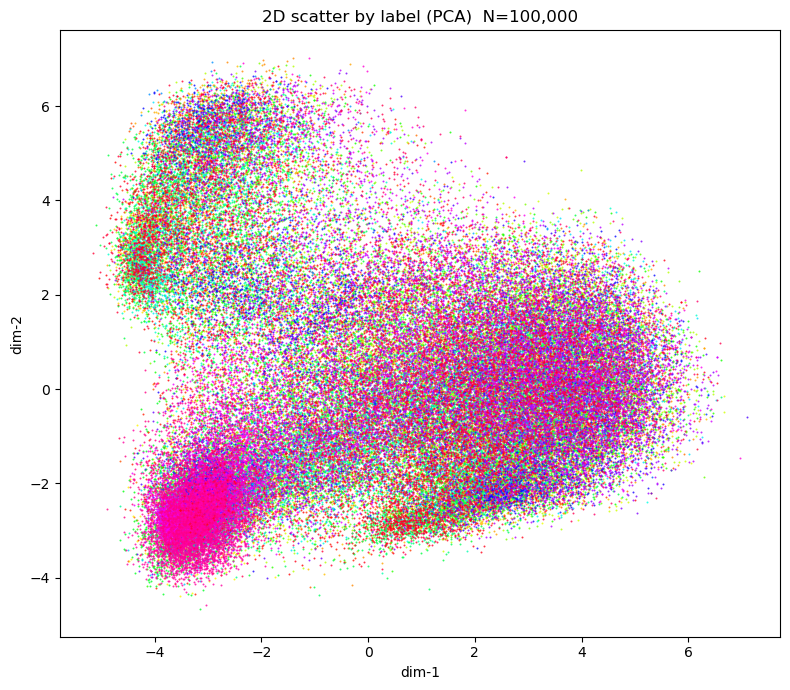

In [ ]:
label_key = "section_name"   # 예: product_type_no, colour_group_code 등

labels = np.array([p[label_key] for p in payloads])
print(f"Labels shape = {labels.shape}")


# ----------------------------------------
# 🔹 4) 분석용 벡터 불러오기
#     (hardness_format/vectors.npy)
# ----------------------------------------
vectors_file = "/home/mintaek/hybrid_index/Benchmark/HnM/hardness_format/vectors.npy"
vectors = np.load(vectors_file)
print(f"Vectors shape = {vectors.shape}")


# ----------------------------------------
# 🔹 5) 시각화 실행
# ----------------------------------------
scatter_2d_by_label(
    vectors,
    labels,
    method="pca",   # "pca" 또는 "umap"
    sample_max=100000,
    # point_size=2.0,
    alpha=0.8,
)
